SUPRIYA K 
24BAD118
Accuracy: 0.968609865470852

Classification Report:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.77      0.87       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.93      1115
weighted avg       0.97      0.97      0.97      1115



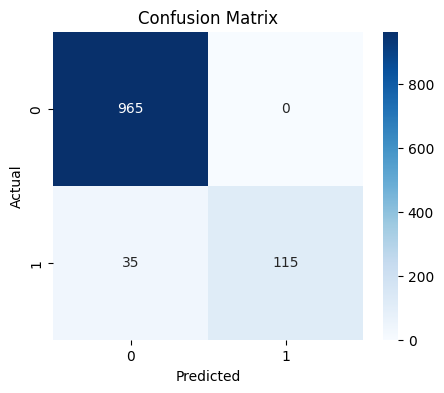


Misclassified Messages:
free entry in  a wkly comp to win fa cup final tkts st may  text fa to  to receive entry questionstd txt ratetcs apply overs
k tell me anything about you
gud mrng dear hav a nice day
there is os called ubandu which will run without installing in hard diskyou can use that os to copy the important files in system and give it to repair shop
would really appreciate if you call me just need someone to talk to


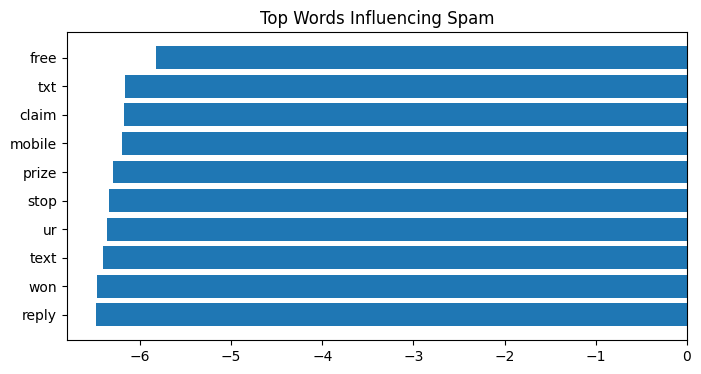

In [3]:
print("SUPRIYA K \n24BAD118")
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
df = pd.read_csv("spam.csv", encoding='latin-1')
df = df[['v1','v2']]
df.columns = ['label','message']
def clean_text(text):
    text = text.lower()
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\d+', '', text)   
    return text
df['message'] = df['message'].apply(clean_text)
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['message'])
encoder = LabelEncoder()
y = encoder.fit_transform(df['label'])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
model = MultinomialNB(alpha=1.0)   
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

misclassified = np.where(y_test != y_pred)[0]
print("\nMisclassified Messages:")
for i in misclassified[:5]:
    print(df.iloc[i]['message'])

feature_names = vectorizer.get_feature_names_out()
spam_words = model.feature_log_prob_[1]

top_spam = np.argsort(spam_words)[-10:]

plt.figure(figsize=(8,4))
plt.barh(feature_names[top_spam], spam_words[top_spam])
plt.title("Top Words Influencing Spam")
plt.show()

Feature Names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



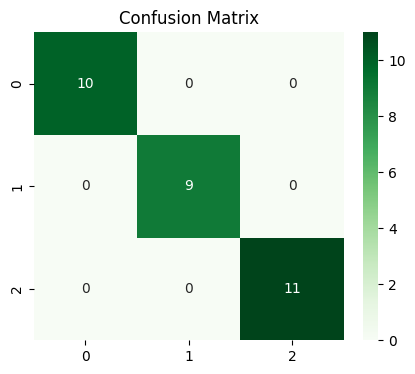


Class Probabilities:
 [[5.97322611e-090 9.95635768e-001 4.36423247e-003]
 [1.00000000e+000 4.96157683e-014 6.54921950e-021]
 [7.31861098e-290 4.92947289e-012 1.00000000e+000]
 [2.81838335e-094 9.77593560e-001 2.24064404e-002]
 [1.13876385e-105 8.70022604e-001 1.29977396e-001]]

Logistic Regression Accuracy: 1.0


In [4]:
print("SUPRIYA K \n24BAD118")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

iris = load_iris()
X = iris.data
y = iris.target

print("Feature Names:", iris.feature_names)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

gnb = GaussianNB()
gnb.fit(X_train, y_train)

y_pred = gnb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix")
plt.show()

probabilities = gnb.predict_proba(X_test[:5])
print("\nClass Probabilities:\n", probabilities)

lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("\nLogistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))